In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week5/abalone.csv')

df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [42]:
df2=df.drop('Rings',axis=1)
df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [43]:
y=df2['Height']
y.value_counts()
y

,Height
0,0.095
1,0.090
2,0.135
3,0.125
4,0.080
...,...
4172,0.165
4173,0.135
4174,0.205
4175,0.150


In [44]:
X=df2.drop('Height',axis=1)
X.head()

,id,Sex,Length,Diameter,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,0,M,0.455,0.365,0.5140,0.2245,0.1010,0.150
1,1,M,0.350,0.265,0.2255,0.0995,0.0485,0.070
2,2,F,0.530,0.420,0.6770,0.2565,0.1415,0.210
3,3,M,0.440,0.365,0.5160,0.2155,0.1140,0.155
4,4,I,0.330,0.255,0.2050,0.0895,0.0395,0.055


In [45]:
# 성별(Sex)만 원-핫 인코딩
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

In [46]:
scaler = StandardScaler() # 각 특성(열)의 평균을 0, 표준편차를 1로 맞추기 위한 객체 생성
X = scaler.fit_transform(X) # 그 값을 이용해 데이터를 표준화(transform)

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [48]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3341, 9), (3341,), (836, 9), (836,))

은닉층을 6개의 층으로, 뉴런을 64-128-256-128-64-32로 설정

In [49]:
# 모델 정의

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam

# Sequential 모델 생성
# 층을 순서대로 쌓는 가장 기본적인 신경망 모델
model = Sequential()

# 입력층 + 첫 번째 은닉층
# 뉴런 64개, 입력 데이터의 특성 개수는 X.shape[1]
# 활성화 함수는 ReLU 사용
model.add(Dense(64, input_shape=(X.shape[1],), activation='relu'))

# 두 번째 은닉층
# 뉴런 128개, 활성화 함수는 ReLU
layers.Dense(128, activation="relu"),

# 세 번째 은닉층
# 뉴런 256개, 활성화 함수는 ReLU
layers.Dense(256, activation="relu"),

# 네 번째 은닉층
# 뉴런 128개, 활성화 함수는 ReLU
layers.Dense(128, activation="relu"),

# 다섯 번째 은닉층
# 뉴런 64개, 활성화 함수는 ReLU
layers.Dense(64, activation="relu"),

# 여섯 번째 은닉층
# 뉴런 32개, 활성화 함수는 ReLU
layers.Dense(32, activation="relu"),

# 출력층
# 뉴런 1개이므로 회귀 문제에 적합한 형태
model.add(Dense(1))

# 모델 학습 설정
# optimizer: 가중치 갱신 방법으로 rmsprop 사용
# loss: 손실 함수로 평균제곱오차(mse) 사용
# metrics: 학습 과정에서 mse를 함께 출력
model.compile(optimizer='rmsprop', loss='mse', metrics=['mse'])

# 모델 구조 요약 출력
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0335 - mse: 0.0335 - val_loss: 0.0028 - val_mse: 0.0028
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mse: 0.0028 - val_loss: 0.0028 - val_mse: 0.0028
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - mse: 0.0019 - val_loss: 0.0015 - val_mse: 0.0015
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - mse: 0.0016 - val_loss: 8.1061e-04 - val_mse: 8.1061e-04
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 7.5401e-04 - val_mse: 7.5401e-04
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.0015 - val_mse: 0.0015
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mse: 0.0012 - val_loss: 0.0012 - val_mse: 0.0012
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mse: 0.0012 - val_loss: 0.0015 - val_mse: 0.0015
Epoch 9/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 

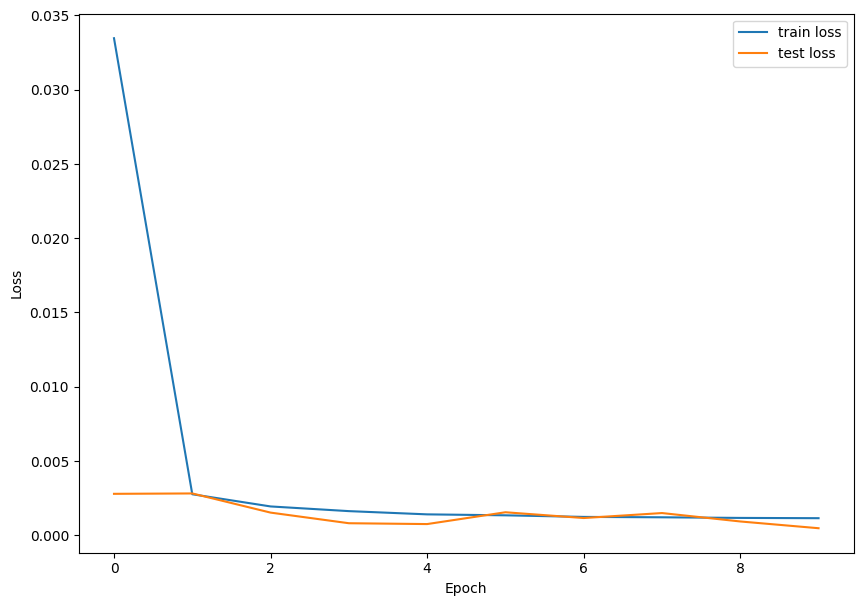

In [51]:
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [52]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7448e-04 - mse: 4.7448e-04 


[0.00047448137775063515, 0.00047448137775063515]